In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [7]:
prophet_model = joblib.load("../models/prophet_model.pkl")
future = prophet_model.make_future_dataframe(periods=30)
forecast_prophet = prophet_model.predict(future)
prophet_preds = forecast_prophet[['ds', 'yhat']].tail(30)
prophet_preds.head()

,ds,yhat
275,2011-11-05,57534.012502
276,2011-11-06,26649.928541
277,2011-11-07,41904.568208
278,2011-11-08,47836.914826
279,2011-11-09,41656.237290


In [8]:
lstm_model = load_model("../models/lstm_model.keras")

In [13]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361461 entries, 0 to 361460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    361461 non-null  int64  
 1   stockcode    361461 non-null  object 
 2   description  361461 non-null  object 
 3   quantity     361461 non-null  int64  
 4   invoicedate  361461 non-null  object 
 5   unitprice    361461 non-null  float64
 6   customerid   361461 non-null  float64
 7   country      361461 non-null  object 
 8   revenue      361461 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 24.8+ MB


In [12]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [14]:
daily_sales = df.groupby('invoicedate')['revenue'].sum().reset_index()

In [16]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(daily_sales[['revenue']])

In [17]:
sequence_length = 30
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])
X = np.array(X)
y = np.array(y)

In [18]:
current_seq = X[-1]
lstm_preds = []
for _ in range(30):

    pred = lstm_model.predict(
        current_seq.reshape(1, sequence_length, 1),
        verbose=0
    )

    pred_value = pred[0][0]

    lstm_preds.append(pred_value)

    current_seq = np.append(
        current_seq[1:],
        pred_value
    )

    current_seq = current_seq.reshape(sequence_length, 1)

In [19]:
lstm_preds = scaler.inverse_transform(np.array(lstm_preds).reshape(-1,1))
lstm_preds = lstm_preds.flatten()

In [20]:
hybrid_preds = []
for p, l in zip(prophet_preds['yhat'], lstm_preds):

    hybrid = (0.5 * p) + (0.5 * l)

    hybrid_preds.append(hybrid)

In [21]:
final_forecast = pd.DataFrame({

    'date': prophet_preds['ds'].values,

    'prophet_prediction': prophet_preds['yhat'].values,

    'lstm_prediction': lstm_preds,

    'hybrid_prediction': hybrid_preds
})
final_forecast.head()

,date,prophet_prediction,lstm_prediction,hybrid_prediction
0,2011-11-05,57534.012502,494.459839,29014.236328
1,2011-11-06,26649.928541,496.795776,13573.361328
2,2011-11-07,41904.568208,504.382721,21204.474609
3,2011-11-08,47836.914826,516.245789,24176.580078
4,2011-11-09,41656.237290,530.677368,21093.457031


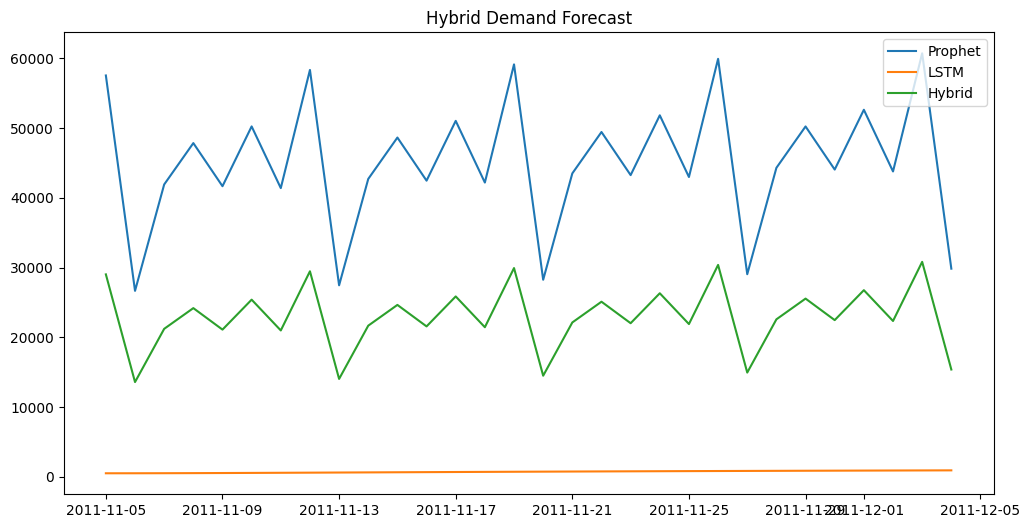

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    final_forecast['date'],
    final_forecast['prophet_prediction'],
    label='Prophet'
)

plt.plot(
    final_forecast['date'],
    final_forecast['lstm_prediction'],
    label='LSTM'
)

plt.plot(
    final_forecast['date'],
    final_forecast['hybrid_prediction'],
    label='Hybrid'
)

plt.legend()

plt.title("Hybrid Demand Forecast")

plt.show()

In [23]:
final_forecast.to_csv(
    "../data/processed/hybrid_forecast.csv",
    index=False
)

In [26]:
import mlflow

mlflow.set_experiment("RetailPulse")

with mlflow.start_run(run_name="Hybrid_Forecast_Model"):

    mlflow.log_artifact("../data/processed/hybrid_forecast.csv")